# ODSB-16939: Ad Group Spending Issue — YANOLJA

| Field | Value |
|-------|-------|
| **Author** | Haewon |
| **Last update** | 2026-03-16 |
| **Objective** | Replicate CRU report analysis: why AG1 (`AI8JyV98HDBLOusH`) spend did not increase despite user_buckets expansion |
| **Scope** | Campaign `hnV6nWYN0VYULKpr` (RE_ROAS, Android, YANOLJA), 2026-02-27 to 2026-03-12 |
| **Out of scope** | Other campaigns / advertisers |
| **Key tables** | `focal-elf-631.entity_history.prod_entity_history`, `focal-elf-631.mems_prod.api_log`, `moloco-ae-view.athena.fact_dsp_core`, `moloco-ae-view.athena.fact_dsp_creative`, `moloco-data-prod.younghan.spending_summary`, `moloco-data-prod.younghan.campaign_trace_raw_prod` |
| **Additional context** | Root causes: cold-start vicious cycle (zero revenue → low predictions → low bids), zero-sum traffic reallocation (AG5 removed), CustomerSetIDs binding constraint, saturated campaign budget, Red Buttons on Mar 10 |

## Root Cause Summary (from CRU report)
- AG1 has $0 D7 revenue → model prediction 10-15x lower than peers → avg bid CPM $0.43 vs $3.00–$3.65 for others
- Traffic expansion 0-25 → 0-40 → 0-50 was **zero-sum**: AG5 (25-50) removed simultaneously
- CustomerSetIDs filter rose from 25.8% → 43.0% after expansion (binding constraint)
- Campaign budget (140K KRW/day) is 97-103% consumed by high-ROAS ad groups
- Red Buttons emergency filter on Mar 10 (deactivated Mar 11, not ongoing)

## Ad Group Comparison (Mar 5–12)
| Ad Group | Spend | Revenue D7 | ROAS | Avg Prediction | Avg Bid CPM | Win Rate |
|----------|-------|-----------|------|---------------|-------------|----------|
| SHZl2IfvqV3SRPV4 | $776 | $108,789 | 140x | 0.19 | $3.65 | ~5% |
| oAEsyWQ5LPYmrQTR | $596 | $95,572 | 160x | 0.18 | $3.30 | ~5% |
| NdXm7TtWMn20C2FI | $223 | $29,551 | 133x | 0.17 | $3.15 | ~5% |
| jH5XJxRKQt9ABhhS | $171 | $17,481 | 102x | 0.16 | $3.00 | ~5% |
| zotvA86ohDsn09sG | $160 | $19,777 | 123x | 0.16 | $3.10 | ~5% |
| **AI8JyV98HDBLOusH** | **$6** | **$0** | **0x** | **0.014** | **$0.43** | **2.58%** |

In [18]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [19]:
client = bigquery.Client(project="moloco-ods")

def run_query(query, label=''):
    df = client.query(query).result().to_dataframe()
    print(f'✅ {label}: {len(df)} rows')
    return df

# Key parameters
CAMPAIGN_ID = 'hnV6nWYN0VYULKpr'
AG1_ID = 'AI8JyV98HDBLOusH'
DATE_START = '2026-02-26'
DATE_END = '2026-03-12'

print('Setup complete.')

Setup complete.


## Query 1 — Entity Changes (Campaign Config History)

Track daily_budget and goal_type changes for campaign `hnV6nWYN0VYULKpr`.

In [20]:
df_entity_campaign = run_query("""
SELECT
  timestamp,
  JSON_VALUE(json_entity, '$.name') AS campaign_id,
  JSON_VALUE(json_entity, '$.display_name') AS display_name,
  JSON_VALUE(json_entity, '$.enable') AS enabled,
  JSON_VALUE(json_entity, '$.capper.user_budget_enforcer.daily_budget') AS daily_budget,
  JSON_VALUE(json_entity, '$.campaign_goal_model.type') AS goal_type
FROM `focal-elf-631.entity_history.prod_entity_history`
WHERE DATE(timestamp) BETWEEN '2026-02-26' AND '2026-03-12'
  AND entity_type = 'RTB_CAMPAIGN'
  AND JSON_VALUE(json_entity, '$.name') = 'hnV6nWYN0VYULKpr'
ORDER BY timestamp ASC
""", 'Q1. Campaign Entity History')

display(df_entity_campaign)

✅ Q1. Campaign Entity History: 395 rows


,timestamp,campaign_id,display_name,enabled,daily_budget,goal_type
0,2026-02-26 00:38:03.521833+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
1,2026-02-26 01:56:54.476296+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
2,2026-02-26 02:38:39.890629+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
3,2026-02-26 03:02:37.601781+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
4,2026-02-26 04:56:03.465164+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
...,...,...,...,...,...,...
390,2026-03-12 12:57:52.910887+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
391,2026-03-12 18:33:12.925563+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
392,2026-03-12 20:57:14.114756+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE
393,2026-03-12 21:58:20.577994+00:00,hnV6nWYN0VYULKpr,RE-roas-android-outbound,true,140000,OPTIMIZE_ROAS_FOR_APP_RE


## Query 2 — MEMS API Audit Log

All config changes to campaign and AG1 via the MEMS API (e.g., user_buckets expansions).

In [21]:
df_mems = run_query("""
SELECT
  timestamp,
  REGEXP_EXTRACT(method, r'/([^/]+)$') AS method_name,
  caller,
  user_name,
  status,
  JSON_VALUE(request, '$.update_mask') AS update_mask,
  request AS request_full
FROM `focal-elf-631.mems_prod.api_log`
WHERE DATE(timestamp) BETWEEN '2026-02-26' AND '2026-03-12'
  AND ((method LIKE '%Campaign%' AND JSON_VALUE(request, '$.campaign.name') = 'hnV6nWYN0VYULKpr')
    OR (method LIKE '%AdGroup%' AND JSON_VALUE(request, '$.ad_group.name') = 'AI8JyV98HDBLOusH'))
ORDER BY timestamp DESC
LIMIT 50
""", 'Q2. MEMS API Audit Log')

# Show full request content without truncation
pd.set_option('display.max_colwidth', None)
display(df_mems)

✅ Q2. MEMS API Audit Log: 5 rows


,timestamp,method_name,caller,user_name,status,update_mask,request_full
0,2026-03-11 05:52:27.829618+00:00,UpdateAdGroup,/cm.v1.DspApi/UpdateAdGroup,min@dable.io,OK,None,"{""platform_id"":""YANOLJA"",""ad_group_id"":""AI8JyV98HDBLOusH"",""ad_group"":{""campaign_name"":""hnV6nWYN0VYULKpr"",""product_name"":""pbcNuBii40o8VzYy"",""advertiser_name"":""Os7oojpjTo8JwHIt"",""name"":""AI8JyV98HDBLOusH"",""display_name"":""g_cross-always-NOLINTGCVdapps_OP30d-260227"",""creative_groups"":[""QXzpDpDb6RmAC3CT"",""JrRmyEV0jPBx1hvt"",""vaSQdpBcKyrUoIBS"",""W08KZo6wcYjfV1fa"",""AjnZXxndgHxYHJ9Y"",""JpvAOYXYU8euSAa2"",""ludcQWCwBJmMjTsa"",""MPVvM0xyPPnA0L89"",""nlaHW7Ty14n5gRSB"",""xd8iwJRdU9Afzupk"",""NC6zi2TrKQpPaFBT"",""R2DqZWNdovhzKgVz"",""SkFAR89xxhCWOVzB"",""y7AqXyExLWJa1r31"",""erhgxdI96s9dcDT5"",""bdemH73UCGuhsT2h"",""lVoeqDiNciZV5xcq"",""uyxWGZ2j5ZRw0Czo""],""pricing_order"":{""pricing_model_name"":""cloud_v1"",""max_cpm"":70},""capper"":{""imp_interval"":""6h""},""user_targets"":[""rSAh2C5FmXvzj3Gk""],""user_buckets"":[{""end"":50}],""created_timestamp_nano"":""1772164268241475000"",""updated_timestamp_nano"":""1773040282166692000"",""publisher_properties"":{}}}"
1,2026-03-09 07:11:22.251346+00:00,UpdateAdGroup,/cm.v1.DspApi/UpdateAdGroup,min@dable.io,OK,None,"{""platform_id"":""YANOLJA"", ""ad_group_id"":""AI8JyV98HDBLOusH"", ""ad_group"":{""campaign_name"":""hnV6nWYN0VYULKpr"", ""product_name"":""pbcNuBii40o8VzYy"", ""advertiser_name"":""Os7oojpjTo8JwHIt"", ""name"":""AI8JyV98HDBLOusH"", ""display_name"":""g_cross-always-NOLINTGCVdapps_OP30d-260227"", ""creative_groups"":[""QXzpDpDb6RmAC3CT"", ""JrRmyEV0jPBx1hvt"", ""vaSQdpBcKyrUoIBS"", ""W08KZo6wcYjfV1fa"", ""AjnZXxndgHxYHJ9Y"", ""JpvAOYXYU8euSAa2"", ""ludcQWCwBJmMjTsa"", ""MPVvM0xyPPnA0L89"", ""nlaHW7Ty14n5gRSB"", ""xd8iwJRdU9Afzupk"", ""NC6zi2TrKQpPaFBT"", ""R2DqZWNdovhzKgVz"", ""SkFAR89xxhCWOVzB"", ""y7AqXyExLWJa1r31"", ""erhgxdI96s9dcDT5"", ""bdemH73UCGuhsT2h"", ""lVoeqDiNciZV5xcq"", ""uyxWGZ2j5ZRw0Czo""], ""pricing_order"":{""pricing_model_name"":""cloud_v1"", ""max_cpm"":70}, ""capper"":{""imp_interval"":""6h""}, ""user_targets"":[""rSAh2C5FmXvzj3Gk""], ""user_buckets"":[{""end"":40}], ""created_timestamp_nano"":""1772164268241475000"", ""updated_timestamp_nano"":""1772606662584239000"", ""publisher_properties"":{}}}"
2,2026-03-03 09:09:14.038161+00:00,UpdateAdGroup,/cm.v1.DspApi/UpdateAdGroup,min@dable.io,OK,None,"{""platform_id"":""YANOLJA"", ""ad_group_id"":""AI8JyV98HDBLOusH"", ""ad_group"":{""campaign_name"":""hnV6nWYN0VYULKpr"", ""product_name"":""pbcNuBii40o8VzYy"", ""advertiser_name"":""Os7oojpjTo8JwHIt"", ""name"":""AI8JyV98HDBLOusH"", ""display_name"":""g_cross-always-NOLINTGCVdapps_OP30d-260227"", ""creative_groups"":[""JrRmyEV0jPBx1hvt"", ""vaSQdpBcKyrUoIBS"", ""W08KZo6wcYjfV1fa"", ""AjnZXxndgHxYHJ9Y"", ""JpvAOYXYU8euSAa2"", ""ludcQWCwBJmMjTsa"", ""MPVvM0xyPPnA0L89"", ""nlaHW7Ty14n5gRSB"", ""xd8iwJRdU9Afzupk"", ""NC6zi2TrKQpPaFBT"", ""R2DqZWNdovhzKgVz"", ""SkFAR89xxhCWOVzB"", ""y7AqXyExLWJa1r31"", ""erhgxdI96s9dcDT5"", ""bdemH73UCGuhsT2h"", ""lVoeqDiNciZV5xcq"", ""uyxWGZ2j5ZRw0Czo""], ""pricing_order"":{""pricing_model_name"":""cloud_v1"", ""max_cpm"":70}, ""capper"":{""imp_interval"":""6h""}, ""user_targets"":[""rSAh2C5FmXvzj3Gk""], ""user_buckets"":[{""end"":25}], ""created_timestamp_nano"":""1772164268241475000"", ""updated_timestamp_nano"":""1772174473859164000"", ""publisher_properties"":{}}}"
3,2026-02-27 06:13:33.241543+00:00,UpdateAdGroup,/cm.v1.DspApi/UpdateAdGroup,min@dable.io,OK,None,"{""platform_id"":""YANOLJA"",""ad_group_id"":""AI8JyV98HDBLOusH"",""ad_group"":{""campaign_name"":""hnV6nWYN0VYULKpr"",""product_name"":""pbcNuBii40o8VzYy"",""advertiser_name"":""Os7oojpjTo8JwHIt"",""name"":""AI8JyV98HDBLOusH"",""display_name"":""g_cross-always-NOLINTGCVdapps_OP30d-260227"",""creative_groups"":[""AjnZXxndgHxYHJ9Y"",""JpvAOYXYU8euSAa2"",""ludcQWCwBJmMjTsa"",""MPVvM0xyPPnA0L89"",""nlaHW7Ty14n5gRSB"",""xd8iwJRdU9Afzupk"",""NC6zi2TrKQpPaFBT"",""R2DqZWNdovhzK

## Query 3 — Campaign Daily Spending

Daily spend, impressions, bids at the campaign level.

✅ Q3. Campaign Daily Spending: 15 rows


,date_utc,total_spend_usd,total_impressions,total_bids
0,2026-03-12,95.960000000,21080,443200
1,2026-03-11,98.370000000,23930,484200
2,2026-03-10,63.070000000,16138,312600
3,2026-03-09,94.770000000,24290,533700
4,2026-03-08,96.280000000,27277,561300
5,2026-03-07,96.400000000,29432,629400
6,2026-03-06,95.140000000,26671,647800
7,2026-03-05,93.130000000,26780,608700
8,2026-03-04,95.300000000,33086,659900
9,2026-03-03,95.230000000,47734,1030800


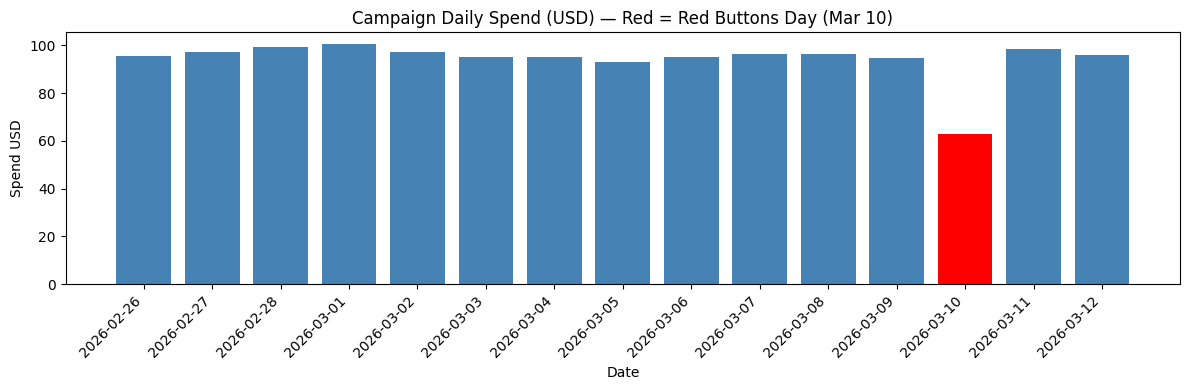

In [22]:
df_campaign_daily = run_query("""
SELECT
  date_utc,
  ROUND(SUM(gross_spend_usd), 2) AS total_spend_usd,
  SUM(impressions) AS total_impressions,
  SUM(bids) AS total_bids
FROM `moloco-ae-view.athena.fact_dsp_core`
WHERE date_utc BETWEEN '2026-02-26' AND '2026-03-12'
  AND campaign_id = 'hnV6nWYN0VYULKpr'
GROUP BY 1
ORDER BY 1 DESC
""", 'Q3. Campaign Daily Spending')

display(df_campaign_daily)

# Plot budget utilization (140K KRW ≈ ~$107 USD at ~1310 KRW/USD)
if not df_campaign_daily.empty:
    df_plot = df_campaign_daily.sort_values('date_utc')
    fig, ax = plt.subplots(figsize=(12, 4))
    colors = ['red' if str(d) == '2026-03-10' else 'steelblue' for d in df_plot['date_utc']]
    ax.bar(df_plot['date_utc'].astype(str), df_plot['total_spend_usd'], color=colors)
    ax.set_title('Campaign Daily Spend (USD) — Red = Red Buttons Day (Mar 10)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Spend USD')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Query 4 — AG1 Daily Spending

Daily spend for AG1 (`AI8JyV98HDBLOusH`) — expected to be near-zero throughout.

In [23]:
df_ag1_daily = run_query("""
SELECT
  date_utc,
  ROUND(SUM(gross_spend_usd), 2) AS spend_usd,
  SUM(impressions) AS impressions,
  SUM(clicks) AS clicks,
  SUM(bids) AS bids
FROM `moloco-ae-view.athena.fact_dsp_core`
WHERE date_utc BETWEEN '2026-02-26' AND '2026-03-12'
  AND campaign_id = 'hnV6nWYN0VYULKpr'
  AND ad_group.id = 'AI8JyV98HDBLOusH'
GROUP BY 1
ORDER BY 1 DESC
""", 'Q4. AG1 Daily Spending')

print(f'AG1 total spend: ${df_ag1_daily["spend_usd"].sum():.2f}')
display(df_ag1_daily)

✅ Q4. AG1 Daily Spending: 14 rows
AG1 total spend: $8.47


,date_utc,spend_usd,impressions,clicks,bids
0,2026-03-12,2.550000000,1848,205,87400
1,2026-03-11,1.250000000,2233,122,76500
2,2026-03-10,0.490000000,796,44,29100
3,2026-03-09,0.790000000,1227,108,61300
4,2026-03-08,0.350000000,785,40,28700
5,2026-03-07,0.650000000,1326,96,49400
6,2026-03-06,0.440000000,766,64,37200
7,2026-03-05,0.250000000,728,36,26200
8,2026-03-04,0.500000000,1451,80,48600
9,2026-03-03,0.430000000,1544,72,48400


## Query 5 — Performance Metrics by Ad Group (Mar 5–12)

Reproduces the ad group comparison table from the report: spend, revenue D7, ROAS, CTR.

In [24]:
df_ag_perf = run_query("""
SELECT
  ad_group.id AS ad_group_id,
  ad_group.title AS ad_group_title,
  SUM(gross_spend_usd) AS total_spend_usd,
  SUM(impressions) AS total_impressions,
  SUM(clicks) AS total_clicks,
  SUM(kpi_actions) AS total_kpi_actions,
  SUM(kpi_pb_revenue_d7) AS total_kpi_revenue_d7,
  SAFE_DIVIDE(SUM(clicks), SUM(impressions))*100 AS ctr_pct,
  SAFE_DIVIDE(SUM(kpi_pb_revenue_d7), SUM(gross_spend_usd)) AS roas_d7
FROM `moloco-ae-view.athena.fact_dsp_creative`
WHERE campaign_id = 'hnV6nWYN0VYULKpr'
  AND date_utc BETWEEN '2026-02-26' AND '2026-03-12'
GROUP BY 1, 2
ORDER BY total_spend_usd DESC
""", 'Q5. Ad Group Performance Comparison')

# Highlight AG1
def highlight_ag1(row):
    return ['font-weight: bold; background-color: #fff3cd' if row['ad_group_id'] == 'AI8JyV98HDBLOusH' else '' for _ in row]

if not df_ag_perf.empty:
    display(df_ag_perf.style.apply(highlight_ag1, axis=1))

✅ Q5. Ad Group Performance Comparison: 6 rows


,ad_group_id,ad_group_title,total_spend_usd,total_impressions,total_clicks,total_kpi_actions,total_kpi_revenue_d7,ctr_pct,roas_d7
0,SHZl2IfvqV3SRPV4,tna-always-TNACV90dorTRIP30d-260210,564.509901192,195639,32187,2513,83771.685488783,16.452241,148.397194295
1,oAEsyWQ5LPYmrQTR,g_cross-always-NOLINTGCVdapps_None-260115,439.625680943,153590,23720,1566,77609.164220656,15.443714,176.534646598
2,jH5XJxRKQt9ABhhS,pkg-pdp_pkg-GLCV180d_GLPU7d-251217,190.345747382,55040,8866,368,22314.592460310,16.108285,117.231893894
3,NdXm7TtWMn20C2FI,tna-always-JPCV90d_None-260210,187.614826840,64122,12397,376,26926.494606399,19.333458,143.520078130
4,zotvA86ohDsn09sG,pkg-pdp_pkg-GLCV180d_GLPU7d-251217,22.638784759,8315,1538,414,2721.672480010,18.496693,120.221668653
5,AI8JyV98HDBLOusH,g_cross-always-NOLINTGCVdapps_OP30d-260227,8.450188477,16094,1059,1,0E-9,6.580092,0E-9


## Query 6 — TCM Throttling Analysis

Check if campaign was being throttled (TCM < 1) during the investigation period.

In [25]:
df_tcm = run_query("""
SELECT
  date,
  ROUND(AVG(tcm), 4) AS avg_tcm,
  ROUND(MIN(tcm_1), 4) AS min_tcm_p1,
  ROUND(MAX(tcm_99), 4) AS max_tcm_p99,
  COUNTIF(tcm < 1) AS throttled_minutes,
  COUNT(*) AS total_minutes
FROM `moloco-data-prod.younghan.spending_summary`
WHERE campaign = 'hnV6nWYN0VYULKpr'
  AND date BETWEEN '2026-02-26' AND '2026-03-12'
GROUP BY 1
ORDER BY 1 DESC
""", 'Q6. TCM Throttling')

display(df_tcm)

✅ Q6. TCM Throttling: 15 rows


,date,avg_tcm,min_tcm_p1,max_tcm_p99,throttled_minutes,total_minutes
0,2026-03-12,0.0287,0.0172,0.0385,1347,1440
1,2026-03-11,0.0327,0.0221,0.0445,1440,1440
2,2026-03-10,0.0204,0.0010,0.0342,1214,1219
3,2026-03-09,0.0184,0.0111,0.0262,1419,1440
4,2026-03-08,0.0160,0.0100,0.0228,1359,1440
5,2026-03-07,0.0188,0.0100,0.0246,1354,1440
6,2026-03-06,0.0215,0.0129,0.0349,1327,1440
7,2026-03-05,0.0234,0.0135,0.0328,1440,1440
8,2026-03-04,0.0239,0.0131,0.0321,1326,1440
9,2026-03-03,0.0193,0.0092,0.0358,1439,1440


## Query 7 — Filter Funnel (Daily, AG1)

Daily filter funnel for AG1 — shows which filter stages are blocking most traffic and how volumes shift.

In [26]:
df_funnel = run_query("""
SELECT
  date,
  reason_order,
  reason,
  ROUND(SUM(1/rate)/1e6, 2) AS req_mil,
  ROUND(SUM(1/rate)*100.0/SUM(SUM(1/rate)) OVER(PARTITION BY date), 2) AS pct
FROM `moloco-data-prod.younghan.campaign_trace_raw_prod`
WHERE date BETWEEN DATE('2026-02-24') AND DATE('2026-03-11')
  AND campaign = 'hnV6nWYN0VYULKpr'
  AND ad_group = 'AI8JyV98HDBLOusH'
GROUP BY 1, 2, 3
ORDER BY date, reason_order
""", 'Q7. Daily Filter Funnel (AG1)')

if not df_funnel.empty:
    # Show top filters by volume on most recent available date
    latest_date = df_funnel['date'].max()
    print(f'\nTop filters on {latest_date}:')
    display(df_funnel[df_funnel['date'] == latest_date].sort_values('req_mil', ascending=False).head(10))

✅ Q7. Daily Filter Funnel (AG1): 91 rows

Top filters on 2026-03-11:


,date,reason_order,reason,req_mil,pct
84,2026-03-11,218,(ad_group) Req,1512.85,53.12
87,2026-03-11,240,(ad_group) Ctx,1291.34,45.34
86,2026-03-11,236,avoided pricing (per cr_format) with limits,24.50,0.86
89,2026-03-11,305,"filter(bidfloor,pricing_model,threshold,pmp)",14.20,0.50
90,2026-03-11,310,priced,4.10,0.14
88,2026-03-11,300,no creative candidates,0.90,0.03
85,2026-03-11,220,cap_imp_interval,0.30,0.01


## Query 8 — Reason 218 Sub-Reason Breakdown (CustomerSetIDs)

Reason 218 = CustomerSetIDs filter. Sub-reason breakdown shows which specific audience lists are blocking.

In [27]:
df_reason218 = run_query("""
SELECT
  date,
  reason_raw,
  ROUND(SUM(1/rate)/1e6, 2) AS req_mil
FROM `moloco-data-prod.younghan.campaign_trace_raw_prod`
WHERE date BETWEEN DATE('2026-02-27') AND DATE('2026-03-11')
  AND campaign = 'hnV6nWYN0VYULKpr'
  AND ad_group = 'AI8JyV98HDBLOusH'
  AND reason_order = '218'
GROUP BY 1, 2
ORDER BY date, req_mil DESC
""", 'Q8. Reason 218 (CustomerSetIDs) Sub-Reason')

display(df_reason218)

✅ Q8. Reason 218 (CustomerSetIDs) Sub-Reason: 22 rows


,date,reason_raw,req_mil
0,2026-02-27,PublisherBundles,20.50
1,2026-02-28,PublisherBundles,31.10
2,2026-03-01,PublisherBundles,24.20
3,2026-03-02,PublisherBundles,24.60
4,2026-03-03,UserBuckets,1301.24
5,2026-03-03,PublisherBundles,32.00
6,2026-03-04,UserBuckets,2146.18
7,2026-03-04,PublisherBundles,29.70
8,2026-03-05,UserBuckets,2445.47
9,2026-03-05,PublisherBundles,34.30


## Query 9 — Before vs After Filter Comparison

Compare filter funnel before (0-25 buckets, Feb 27-28) vs after (0-50 buckets, Mar 4-5).
Key expectation: UserBuckets loosens, CustomerSetIDs rises as binding constraint.

In [28]:
df_before_after = run_query("""
WITH before_data AS (
  SELECT reason_order, reason, SUM(1/rate) AS vol
  FROM `moloco-data-prod.younghan.campaign_trace_raw_prod`
  WHERE date BETWEEN DATE('2026-02-27') AND DATE('2026-02-28')
    AND campaign = 'hnV6nWYN0VYULKpr'
    AND ad_group = 'AI8JyV98HDBLOusH'
  GROUP BY 1, 2
),
after_data AS (
  SELECT reason_order, reason, SUM(1/rate) AS vol
  FROM `moloco-data-prod.younghan.campaign_trace_raw_prod`
  WHERE date BETWEEN DATE('2026-03-04') AND DATE('2026-03-05')
    AND campaign = 'hnV6nWYN0VYULKpr'
    AND ad_group = 'AI8JyV98HDBLOusH'
  GROUP BY 1, 2
)
SELECT
  COALESCE(b.reason_order, a.reason_order) AS reason_order,
  COALESCE(b.reason, a.reason) AS reason,
  ROUND(b.vol/1e6, 2) AS before_mil,
  ROUND(a.vol/1e6, 2) AS after_mil
FROM before_data b
FULL OUTER JOIN after_data a ON b.reason_order = a.reason_order
ORDER BY 1
""", 'Q9. Before vs After Filter Comparison')

if not df_before_after.empty:
    df_before_after['delta'] = df_before_after['after_mil'].fillna(0) - df_before_after['before_mil'].fillna(0)
    display(df_before_after)

✅ Q9. Before vs After Filter Comparison: 8 rows


,reason_order,reason,before_mil,after_mil,delta
0,210,adgroup disabled,378.82,NaN,-378.82
1,218,(ad_group) Req,51.60,4655.65,4604.05
2,220,cap_imp_interval,11.00,0.30,-10.70
3,236,avoided pricing (per cr_format) with limits,87.70,26.40,-61.30
4,240,(ad_group) Ctx,4908.66,1501.05,-3407.61
5,300,no creative candidates,0.20,0.20,0.00
6,305,"filter(bidfloor,pricing_model,threshold,pmp)",47.11,14.20,-32.91
7,310,priced,16.80,6.00,-10.80


## Query 10 — Model Predictions by Ad Group (Mar 11)

Avg bid CPM and pred_final per ad group from reason_order 310 (priced/won stage).
Expectation: AG1 avg_pred_final ~0.014 vs 0.16–0.19 for peers.

In [37]:
# ── Step 1: Sample reason_raw at 310 to verify pred_final field format ───────
df_310_sample = run_query("""
SELECT
  ad_group,
  reason_raw,
  COUNT(*) AS cnt
FROM `moloco-data-prod.younghan.campaign_trace_raw_prod`
WHERE date = DATE('2026-03-11')
  AND campaign = 'hnV6nWYN0VYULKpr'
  AND reason_order = '310'
GROUP BY 1, 2
ORDER BY ad_group, cnt DESC
LIMIT 30
""", 'Q10-debug. reason_raw samples at 310')

pd.set_option('display.max_colwidth', None)
display(df_310_sample)

✅ Q10-debug. reason_raw samples at 310: 30 rows


,ad_group,reason_raw,cnt
0,AI8JyV98HDBLOusH,"bid_price:49, value_price:49, pred_final: 0.00121, max_price:40000, bidfloor:10",2
1,AI8JyV98HDBLOusH,"bid_price:2019, value_price:2019, pred_final: 0.0871, max_price:70000, bidfloor:10",2
2,AI8JyV98HDBLOusH,"bid_price:827, value_price:827, pred_final: 0.0295, max_price:70000, bidfloor:10",1
3,AI8JyV98HDBLOusH,"bid_price:707, value_price:707, pred_final: 0.0307, max_price:70000, bidfloor:10",1
4,AI8JyV98HDBLOusH,"bid_price:223, value_price:223, pred_final: 0.00697, max_price:300000, bidfloor:223",1
5,AI8JyV98HDBLOusH,"bid_price:2884, value_price:2884, pred_final: 0.0608, max_price:70000, bidfloor:1809",1
6,AI8JyV98HDBLOusH,"bid_price:409, value_price:409, pred_final: 0.0135, max_price:70000, bidfloor:10",1
7,AI8JyV98HDBLOusH,"bid_price:30, value_price:30, pred_final: 0.00112, max_price:300000, bidfloor:10",1
8,AI8JyV98HDBLOusH,"bid_price:2201, value_price:2201, pred_final: 0.0678, max_price:70000, bidfloor:10",1
9,AI8JyV98HDBLOusH,"bid_price:164, value_price:164, pred_final: 0.00636, max_price:40000, bidfloor:10",1


## Query 10b — Ad Group Summary Table (Replicates PDF Table)

Combines `fact_dsp_creative` (spend / revenue / ROAS / win rate) with trace logs (avg bid CPM / avg prediction).

> **Note on Avg Prediction:** The PDF's values come from the CRU agent's internal scoring. We extract `pred_final` from `reason_raw` at reason_order=`310` (priced stage, Mar 5–11). Run the debug cell above first to confirm the field name/format in your data. If the regex doesn't match, adjust accordingly.

In [ ]:
df_ag_table = run_query("""
WITH imp_stats AS (
  -- avg prediction + avg bid CPM from prod_stream_view.imp
  -- bid.MODEL.bid_price is micro-USD per impression; /1000 converts to USD CPM
  SELECT
    api.adgroup.id AS ad_group_id,
    ROUND(AVG(pred_log.pred), 3) AS avg_prediction,
    ROUND(AVG(bid.MODEL.bid_price) / 1000, 2) AS avg_bid_cpm_usd
  FROM `focal-elf-631.prod_stream_view.imp`,
    UNNEST(bid.MODEL.prediction_logs) AS pred_log
  WHERE DATE(timestamp) BETWEEN '2026-03-05' AND '2026-03-12'
    AND api.campaign.id = 'hnV6nWYN0VYULKpr'
    AND pred_log.type = 'RE_REVENUE_IMP_PREDICTION'
  GROUP BY 1
),
perf AS (
  -- Spend, Revenue D7, ROAS, CTR, Win Rate from fact_dsp_core
  SELECT
    ad_group.id AS ad_group_id,
    ROUND(SUM(gross_spend_usd))                                              AS spend_usd,
    ROUND(SUM(kpi_pb_revenue_d7))                                            AS revenue_d7_usd,
    ROUND(SAFE_DIVIDE(SUM(kpi_pb_revenue_d7), SUM(gross_spend_usd)))         AS roas_x,
    ROUND(SAFE_DIVIDE(SUM(clicks), SUM(impressions)) * 100, 1)               AS ctr_pct,
    ROUND(SAFE_DIVIDE(SUM(impressions), NULLIF(SUM(bids), 0)) * 100, 2)      AS win_rate_pct
  FROM `moloco-ae-view.athena.fact_dsp_core`
  WHERE campaign_id = 'hnV6nWYN0VYULKpr'
    AND date_utc BETWEEN '2026-03-05' AND '2026-03-12'
  GROUP BY 1
)
SELECT
  p.ad_group_id     AS ad_group,
  p.spend_usd,
  p.revenue_d7_usd,
  p.roas_x,
  i.avg_prediction,
  i.avg_bid_cpm_usd,
  p.win_rate_pct,
  p.ctr_pct
FROM perf p
LEFT JOIN imp_stats i ON p.ad_group_id = i.ad_group_id
ORDER BY p.spend_usd DESC
""", 'Q10b. Ad Group Summary Table')

def fmt_row(row):
    rev = int(row['revenue_d7_usd']) if pd.notna(row['revenue_d7_usd']) else 0
    return pd.Series({
        'Ad Group':       row['ad_group'],
        'Spend':          f"${int(row['spend_usd']):,}"  if pd.notna(row['spend_usd'])       else '—',
        'Revenue D7':     f"${rev:,}",
        'ROAS':           f"{int(row['roas_x'])}x"       if pd.notna(row['roas_x']) and row['roas_x'] > 0 else '0x',
        'Avg Prediction': row['avg_prediction'],
        'Avg Bid CPM':    f"${row['avg_bid_cpm_usd']}"   if pd.notna(row['avg_bid_cpm_usd']) else '—',
        'Win Rate':       f"{row['win_rate_pct']}%"      if pd.notna(row['win_rate_pct'])     else '—',
        'CTR':            f"{row['ctr_pct']}%"           if pd.notna(row['ctr_pct'])          else '—',
    })

df_display = df_ag_table.apply(fmt_row, axis=1)

def highlight_ag1(row):
    style = 'font-weight: bold; background-color: #fff3cd'
    return [style if row['Ad Group'] == 'AI8JyV98HDBLOusH' else '' for _ in row]

display(df_display.style.apply(highlight_ag1, axis=1))

✅ Q10b. Ad Group Summary Table: 6 rows


,Ad Group,Spend,Revenue D7,ROAS,Avg Prediction,Avg Bid CPM,Win Rate,CTR
0,SHZl2IfvqV3SRPV4,$283,"$30,005",106x,0.217000,$3.05,4.82%,18.8%
1,oAEsyWQ5LPYmrQTR,$193,"$30,466",158x,0.225000,$2.84,4.43%,16.7%
2,jH5XJxRKQt9ABhhS,$138,"$12,233",89x,0.231000,$3.34,4.88%,17.7%
3,NdXm7TtWMn20C2FI,$113,"$16,119",143x,0.201000,$2.96,5.91%,20.7%
4,AI8JyV98HDBLOusH,$7,$0,0x,0.025000,$0.52,2.45%,7.4%
5,zotvA86ohDsn09sG,$0,$0,0x,nan,—,—,—


In [45]:
# Exapnd the analysis period

df_ag_table = run_query("""
WITH imp_stats AS (
  -- Single scan: avg prediction + avg bid CPM from prod_stream_view.imp
  -- bid.MODEL.bid_price is micro-USD per impression; /1000 converts to USD CPM
  SELECT
    api.adgroup.id AS ad_group_id,
    ROUND(AVG(pred_log.pred), 3) AS avg_prediction,
    ROUND(AVG(bid.MODEL.bid_price) / 1000, 2) AS avg_bid_cpm_usd
  FROM `focal-elf-631.prod_stream_view.imp`,
    UNNEST(bid.MODEL.prediction_logs) AS pred_log
  WHERE DATE(timestamp) BETWEEN '2026-02-26' AND '2026-03-12'
    AND api.campaign.id = 'hnV6nWYN0VYULKpr'
    AND pred_log.type = 'RE_REVENUE_IMP_PREDICTION'
  GROUP BY 1
),
perf AS (
  -- Spend, Revenue D7, ROAS, CTR, Win Rate from fact_dsp_creative
  SELECT
    ad_group.id AS ad_group_id,
    ROUND(SUM(gross_spend_usd))                                              AS spend_usd,
    ROUND(SUM(kpi_pb_revenue_d7))                                            AS revenue_d7_usd,
    ROUND(SAFE_DIVIDE(SUM(kpi_pb_revenue_d7), SUM(gross_spend_usd)))         AS roas_x,
    ROUND(SAFE_DIVIDE(SUM(clicks), SUM(impressions)) * 100, 1)               AS ctr_pct,
    ROUND(SAFE_DIVIDE(SUM(impressions), NULLIF(SUM(bids), 0)) * 100, 2)      AS win_rate_pct
  FROM `moloco-ae-view.athena.fact_dsp_creative`
  WHERE campaign_id = 'hnV6nWYN0VYULKpr'
    AND date_utc BETWEEN '2026-02-26' AND '2026-03-12'
  GROUP BY 1
)
SELECT
  p.ad_group_id     AS ad_group,
  p.spend_usd,
  p.revenue_d7_usd,
  p.roas_x,
  i.avg_prediction,
  i.avg_bid_cpm_usd,
  p.win_rate_pct,
  p.ctr_pct
FROM perf p
LEFT JOIN imp_stats i ON p.ad_group_id = i.ad_group_id
ORDER BY p.spend_usd DESC
""", 'Q10b. Ad Group Summary Table')

def fmt_row(row):
    rev = int(row['revenue_d7_usd']) if pd.notna(row['revenue_d7_usd']) else 0
    return pd.Series({
        'Ad Group':       row['ad_group'],
        'Spend':          f"${int(row['spend_usd']):,}"  if pd.notna(row['spend_usd'])       else '—',
        'Revenue D7':     f"${rev:,}",
        'ROAS':           f"{int(row['roas_x'])}x"       if pd.notna(row['roas_x']) and row['roas_x'] > 0 else '0x',
        'Avg Prediction': row['avg_prediction'],
        'Avg Bid CPM':    f"${row['avg_bid_cpm_usd']}"   if pd.notna(row['avg_bid_cpm_usd']) else '—',
        'Win Rate':       f"{row['win_rate_pct']}%"      if pd.notna(row['win_rate_pct'])     else '—',
        'CTR':            f"{row['ctr_pct']}%"           if pd.notna(row['ctr_pct'])          else '—',
    })

df_display = df_ag_table.apply(fmt_row, axis=1)

def highlight_ag1(row):
    style = 'font-weight: bold; background-color: #fff3cd'
    return [style if row['Ad Group'] == 'AI8JyV98HDBLOusH' else '' for _ in row]

display(df_display.style.apply(highlight_ag1, axis=1))

✅ Q10b. Ad Group Summary Table: 6 rows


,Ad Group,Spend,Revenue D7,ROAS,Avg Prediction,Avg Bid CPM,Win Rate,CTR
0,SHZl2IfvqV3SRPV4,$565,"$83,772",148x,0.187000,$2.22,4.54%,16.5%
1,oAEsyWQ5LPYmrQTR,$440,"$77,609",177x,0.190000,$2.18,4.28%,15.4%
2,jH5XJxRKQt9ABhhS,$190,"$22,315",117x,0.206000,$2.66,4.71%,16.1%
3,NdXm7TtWMn20C2FI,$188,"$26,926",144x,0.180000,$2.35,5.65%,19.3%
4,zotvA86ohDsn09sG,$23,"$2,722",120x,0.199000,$2.15,4.53%,18.5%
5,AI8JyV98HDBLOusH,$8,$0,0x,0.021000,$0.39,2.54%,6.6%


## Query 11 — Bid Price vs Floor Analysis

From reason_order 305 (bidfloor filter): compare AG1's bid CPM vs floor CPM.
Expectation: AG1 floor_to_bid_ratio >> 1 (floor exceeds bid, can't win).

In [30]:
df_bidfloor = run_query("""
WITH bidfloor_data AS (
  SELECT
    ad_group,
    SAFE_CAST(REGEXP_EXTRACT(reason_raw, r'bidfloor:([0-9.]+)') AS FLOAT64) AS bidfloor_cpm,
    SAFE_CAST(REGEXP_EXTRACT(reason_raw, r'bid_cpm:([0-9.]+)') AS FLOAT64) AS bid_cpm,
    SUM(1/rate) AS vol
  FROM `moloco-data-prod.younghan.campaign_trace_raw_prod`
  WHERE date BETWEEN DATE('2026-03-05') AND DATE('2026-03-11')
    AND campaign = 'hnV6nWYN0VYULKpr'
    AND reason_order = '305'
    AND reason_raw LIKE 'filter: bidfloor%'
  GROUP BY 1, 2, 3
)
SELECT
  ad_group,
  ROUND(SUM(vol*bid_cpm)/SUM(vol), 4) AS weighted_avg_bid_cpm,
  ROUND(SUM(vol*bidfloor_cpm)/SUM(vol), 2) AS weighted_avg_floor_cpm,
  ROUND(SAFE_DIVIDE(SUM(vol*bidfloor_cpm), SUM(vol*bid_cpm)), 1) AS floor_to_bid_ratio
FROM bidfloor_data
GROUP BY 1
ORDER BY 1
""", 'Q11. Bid Price vs Floor Analysis')

display(df_bidfloor)

✅ Q11. Bid Price vs Floor Analysis: 5 rows


,ad_group,weighted_avg_bid_cpm,weighted_avg_floor_cpm,floor_to_bid_ratio
0,AI8JyV98HDBLOusH,0.3109,9.98,32.1
1,NdXm7TtWMn20C2FI,0.3770,10.82,28.7
2,SHZl2IfvqV3SRPV4,0.3718,7.89,21.2
3,jH5XJxRKQt9ABhhS,0.4051,9.06,22.4
4,oAEsyWQ5LPYmrQTR,0.5107,12.63,24.7


## Query 12 — CustomerSetIDs Audience List Config

Latest entity history for AG1 — shows what customer sets are targeted/excluded.

In [31]:
df_customer_sets = run_query("""
SELECT
  timestamp,
  JSON_VALUE(json_entity, '$.name') AS ad_group_id,
  JSON_QUERY(json_entity, '$.customer_set_ids') AS customer_set_ids,
  JSON_QUERY(json_entity, '$.negative_customer_set_ids') AS negative_customer_set_ids
FROM `focal-elf-631.entity_history.prod_entity_history`
WHERE DATE(timestamp) BETWEEN '2026-02-26' AND '2026-03-12'
  AND entity_type = 'RTB_AD_GROUP'
  AND JSON_VALUE(json_entity, '$.name') = 'AI8JyV98HDBLOusH'
ORDER BY timestamp DESC
LIMIT 5
""", 'Q12. CustomerSetIDs Audience Config (AG1)')

display(df_customer_sets)

✅ Q12. CustomerSetIDs Audience Config (AG1): 0 rows


,timestamp,ad_group_id,customer_set_ids,negative_customer_set_ids


## Query 13 — Red Buttons Activity (Mar 10)

Confirm Red Buttons emergency filter was activated on Mar 10 for YANOLJA and deactivated by Mar 11.

In [32]:
df_red_buttons = run_query("""
SELECT
  timestamp,
  JSON_VALUE(json_entity, '$.name') AS config_name,
  JSON_VALUE(json_entity, '$.enabled') AS enabled,
  JSON_QUERY(json_entity, '$.filters') AS filters
FROM `focal-elf-631.entity_history.prod_entity_history`
WHERE DATE(timestamp) = '2026-03-10'
  AND entity_type = 'RED_BUTTON'
  AND (JSON_VALUE(json_entity, '$.platform') = 'YANOLJA'
    OR JSON_VALUE(json_entity, '$.scope') = 'GLOBAL')
ORDER BY timestamp
""", 'Q13. Red Buttons Activity (Mar 10)')

display(df_red_buttons)

✅ Q13. Red Buttons Activity (Mar 10): 0 rows


,timestamp,config_name,enabled,filters
